In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
tf.__version__

'2.8.1'

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

# Option 1: Use a raw string (r"")
training_set = train_datagen.flow_from_directory("dataset/training_set",
                                                 target_size=(64, 64),
                                                 batch_size=32,
                                                 class_mode='binary')

Found 8000 images belonging to 2 classes.


In [12]:
test_datagen = ImageDataGenerator(rescale = 1./255)
test_set = test_datagen.flow_from_directory("dataset/test_set",
                                            target_size = (64, 64),
                                            batch_size = 32,
                                            class_mode = 'binary')

Found 2000 images belonging to 2 classes.


In [13]:
cnn = tf.keras.models.Sequential()
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=[64, 64, 3]))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))
cnn.add(tf.keras.layers.Flatten())
cnn.add(tf.keras.layers.Dense(units=128, activation='relu'))
cnn.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))
cnn.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 31, 31, 32)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 29, 29, 32)        9248      
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 6272)              0         
                                                                 
 dense_2 (Dense)             (None, 128)              

In [14]:
cnn.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [15]:
cnn.fit(x = training_set, validation_data = test_set, epochs = 25)

Epoch 1/25
250/250 [==============================] - 26s 102ms/step - loss: 0.6767 - accuracy: 0.5749 - val_loss: 0.6317 - val_accuracy: 0.6380
Epoch 2/25
250/250 [==============================] - 25s 99ms/step - loss: 0.6031 - accuracy: 0.6730 - val_loss: 0.5542 - val_accuracy: 0.7145
Epoch 3/25
250/250 [==============================] - 24s 96ms/step - loss: 0.5676 - accuracy: 0.7045 - val_loss: 0.5651 - val_accuracy: 0.7150
Epoch 4/25
250/250 [==============================] - 25s 100ms/step - loss: 0.5240 - accuracy: 0.7366 - val_loss: 0.4975 - val_accuracy: 0.7565
Epoch 5/25
250/250 [==============================] - 24s 97ms/step - loss: 0.5037 - accuracy: 0.7519 - val_loss: 0.4944 - val_accuracy: 0.7695
Epoch 6/25
250/250 [==============================] - 24s 98ms/step - loss: 0.4766 - accuracy: 0.7694 - val_loss: 0.4916 - val_accuracy: 0.7750
Epoch 7/25
250/250 [==============================] - 24s 94ms/step - loss: 0.4613 - accuracy: 0.7789 - val_loss: 0.4956 - val_accurac

In [16]:
import numpy as np
from tensorflow.keras.preprocessing import image
test_image = image.load_img("dataset/single_prediction/cat_or_dog_4.jpg", target_size = (64, 64))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
result = cnn.predict(test_image)
training_set.class_indices
if result[0][0] == 1:
  prediction = 'dog'
else:
  prediction = 'cat'

In [17]:
print(prediction)

dog


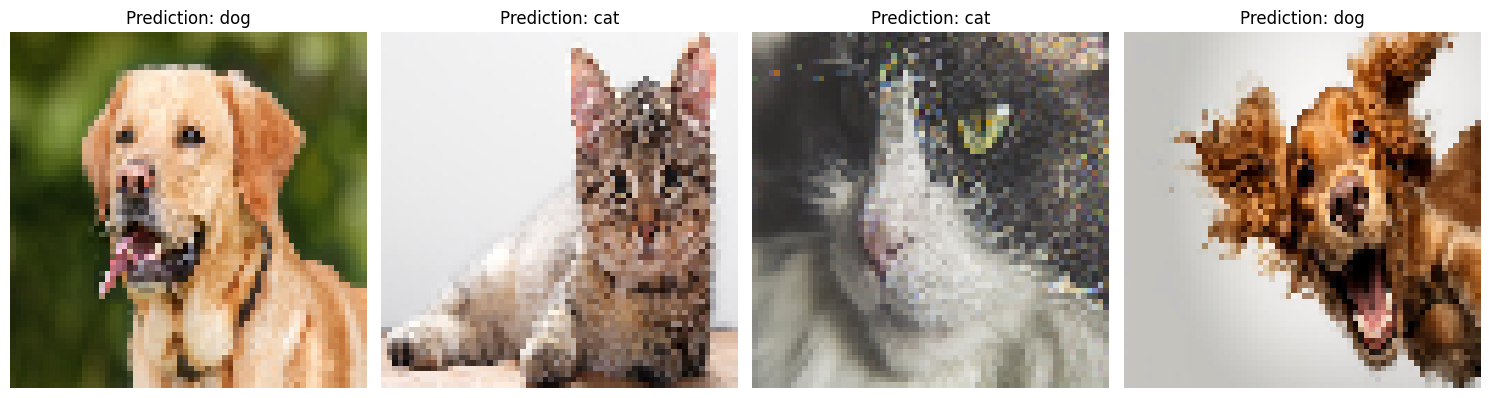

In [18]:
# ... existing code ...

# Add this cell after the prediction code
import matplotlib.pyplot as plt
import os

# Path to the single_prediction folder
prediction_folder = "dataset/single_prediction"

# Get list of images in the folder
image_files = [f for f in os.listdir(prediction_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Display up to 4 images
num_images = min(4, len(image_files))
plt.figure(figsize=(15, 5))

for i, img_file in enumerate(image_files[:num_images]):
    # Load and preprocess the image
    test_image = image.load_img(os.path.join(prediction_folder, img_file), target_size=(64, 64))
    test_image_array = image.img_to_array(test_image)
    test_image_array = np.expand_dims(test_image_array, axis=0)
    
    # Make prediction
    result = cnn.predict(test_image_array)
    prediction = 'dog' if result[0][0] > 0.5 else 'cat'
    
    # Display the image with prediction
    plt.subplot(1, num_images, i+1)
    plt.imshow(test_image)
    plt.title(f'Prediction: {prediction}')
    plt.axis('off')

plt.tight_layout()
plt.show()